# Detect AI vs. Human-Generated Images

## 1. Инсталација и импорти

In [189]:
!pip install -q timm albumentations

In [199]:
!df -h /kaggle

df: /kaggle: No such file or directory


In [200]:
import os

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [201]:
!kaggle datasets download -d alessandrasala79/ai-vs-human-generated-dataset -p /kaggle/working/dataset --unzip
!rm -f /kaggle/working/dataset/*.zip
!df -h /kaggle


Dataset URL: https://www.kaggle.com/datasets/alessandrasala79/ai-vs-human-generated-dataset
License(s): apache-2.0
100%|██████████████████████████████████████▉| 9.76G/9.76G [00:37<00:00, 277MB/s]

Connection error: OSError: [Errno 28] No space left on device
Retrying in 2.6 seconds... (attempt 1/5)
Retry 1/5: Resuming from 10475384832 bytes (4750 bytes left)...
100%|█████████████████████████████████████████████▉| 9.76G/9.76G [00:00<?, ?B/s]

Connection error: OSError: [Errno 28] No space left on device
Retrying in 4.2 seconds... (attempt 2/5)
Retry 2/5: Resuming from 10475384832 bytes (4750 bytes left)...
100%|█████████████████████████████████████████████▉| 9.76G/9.76G [00:00<?, ?B/s]

Connection error: OSError: [Errno 28] No space left on device
Retrying in 8.5 seconds... (attempt 3/5)
Retry 3/5: Resuming from 10475384832 bytes (4750 bytes left)...
100%|█████████████████████████████████████████████▉| 9.76G/9.76G [00:00<?, ?B/s]

Connection error: OSError: [Errno 28] No space left on d

In [202]:
!df -h


Filesystem                                                                Size  Used Avail Use% Mounted on
overlay                                                                   7.9T  6.8T  1.1T  87% /
tmpfs                                                                      64M     0   64M   0% /dev
shm                                                                        14G  116K   14G   1% /dev/shm
/dev/sda1                                                                 122G   24G   99G  20% /opt/bin
/dev/loop1                                                                 20G  9.8G  9.8G  50% /kaggle/lib
/dev/mapper/snap                                                          7.9T  6.8T  1.1T  87% /etc/hosts
tmpfs                                                                      16G     0   16G   0% /proc/acpi
tmpfs                                                                      16G     0   16G   0% /proc/scsi
tmpfs                                                  

In [203]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

✅ Device: cuda
   GPU: Tesla T4


# 2. Конфигурација

In [204]:
class CFG:
    DATA_DIR   = '/kaggle/working/dataset'
    TRAIN_CSV  = '/kaggle/input/competitions/detect-ai-vs-human-generated-images/train.csv'
    TEST_CSV   = '/kaggle/input/competitions/detect-ai-vs-human-generated-images/test.csv'
    TRAIN_DIR  = f'{DATA_DIR}/train_data'
    TEST_DIR   = f'{DATA_DIR}/test_data_v2'
    OUTPUT_DIR = '/tmp'
    MODEL_NAME = 'efficientnet_b3'
    PRETRAINED = True
    DROPOUT    = 0.3
    IMG_SIZE     = 224
    BATCH_SIZE   = 32
    NUM_EPOCHS   = 5
    LR           = 1e-4
    WEIGHT_DECAY = 1e-4
    PATIENCE     = 4
    VAL_SPLIT    = 0.15
    
    THRESHOLD = 0.5

# 3. Вчитување на датасетот

In [205]:
df_train_full = pd.read_csv(CFG.TRAIN_CSV)
df_test       = pd.read_csv(CFG.TEST_CSV)

print(f'Train: {len(df_train_full):,} редови')
print(f'Test:  {len(df_test):,} редови')
print()
print('Train колони:', df_train_full.columns.tolist())
print('Test колони: ', df_test.columns.tolist())
print()
df_train_full.head(10)

Train: 79,950 редови
Test:  5,540 редови

Train колони: ['Unnamed: 0', 'file_name', 'label']
Test колони:  ['id']



,Unnamed: 0,file_name,label
0,0,train_data/a6dcb93f596a43249135678dfcfc17ea.jpg,1
1,1,train_data/041be3153810433ab146bc97d5af505c.jpg,0
2,2,train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg,1
3,3,train_data/8542fe161d9147be8e835e50c0de39cd.jpg,0
4,4,train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg,1
5,5,train_data/25ea852f30594bc5915eb929682af429.jpg,0
6,6,train_data/e67085fb6d814cbabe08f978c738f3f7.jpg,1
7,7,train_data/041c36d9269146cdb88e7526e3b91651.jpg,0
8,8,train_data/4aea3b876247467c8d3713d4920148ab.jpg,1
9,9,train_data/09708379751e44d0bc908d8652d0db3e.jpg,0


In [206]:
df_train_full['path'] = df_train_full['file_name'].apply(
    lambda x: os.path.join(CFG.DATA_DIR, x)
)
df_test['path'] = df_test['id'].apply(
    lambda x: os.path.join(CFG.DATA_DIR, x)
)

exists = df_train_full['path'].apply(os.path.exists).sum()
print(f'✅ Постојат {exists:,} / {len(df_train_full):,} train слики')

print(f'\nРаспределба:')
print(df_train_full['label'].value_counts().rename({0:'REAL (0)', 1:'AI (1)'}))

✅ Постојат 55,635 / 79,950 train слики

Распределба:
label
AI (1)      39975
REAL (0)    39975
Name: count, dtype: int64


In [207]:
exists = df_train_full['path'].apply(os.path.exists).sum()
print(f'Постојат {exists:,} / 79,950 слики')

Постојат 55,635 / 79,950 слики


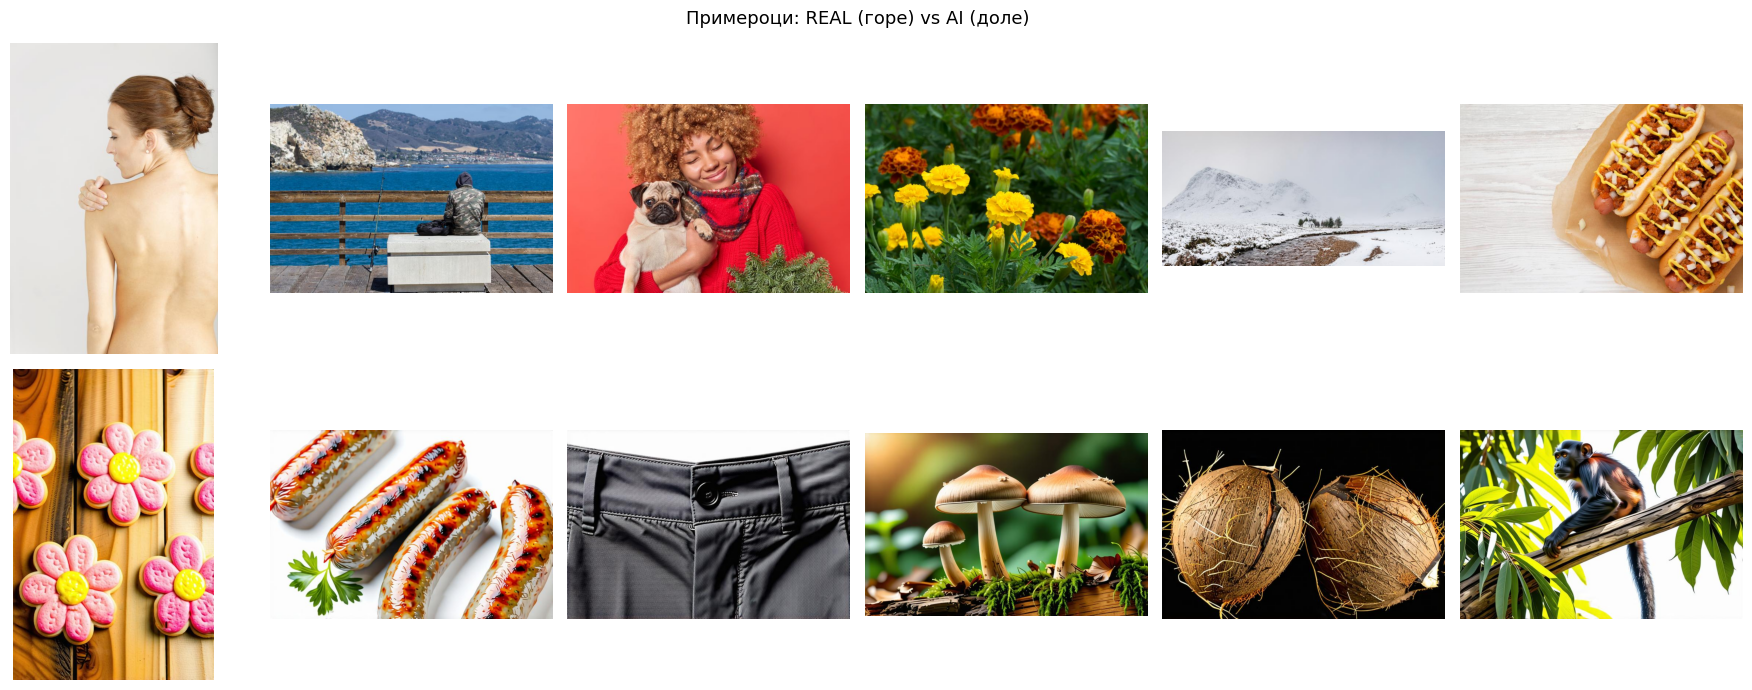

In [208]:
fig, axes = plt.subplots(2, 6, figsize=(18, 7))
for row, label in enumerate([0, 1]):
    subset = df_train_full[
        (df_train_full.label == label) & 
        (df_train_full['path'].apply(os.path.exists))
    ].sample(6, random_state=42)
    
    for col, (_, r) in enumerate(subset.iterrows()):
        img = Image.open(r['path']).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            lbl = 'REAL' if label == 0 else 'AI'
            axes[row, col].set_ylabel(lbl, fontsize=13, fontweight='bold',
                                       color='green' if label==0 else 'red',
                                       rotation=0, labelpad=35)
plt.suptitle('Примероци: REAL (горе) vs AI (доле)', fontsize=13)
plt.tight_layout()
plt.show()

In [209]:
df_train_full = df_train_full[
    df_train_full['path'].apply(os.path.exists)
].reset_index(drop=True)

print(len(df_train_full))

55635


In [210]:
df_train, df_val = train_test_split(
    df_train_full,
    test_size=CFG.VAL_SPLIT,
    stratify=df_train_full['label'],
    random_state=42
)
print(f'Train: {len(df_train):,} | Val: {len(df_val):,}')

Train: 47,289 | Val: 8,346


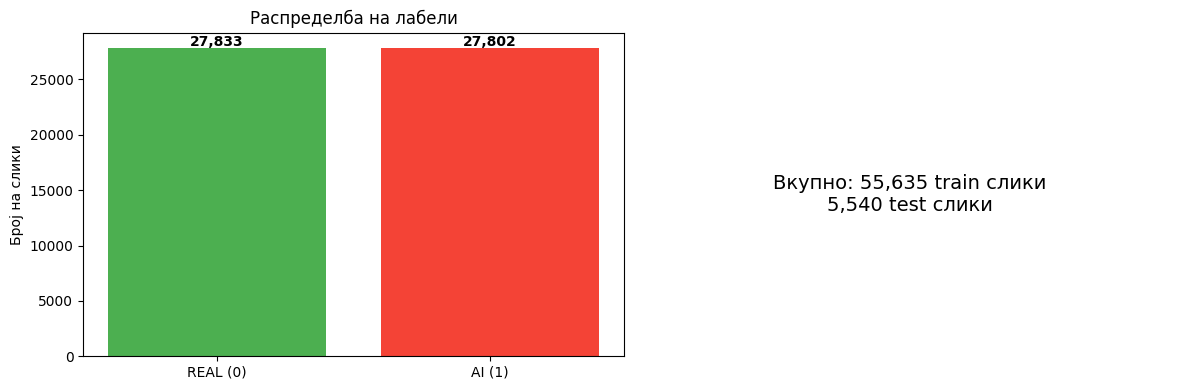

In [211]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_train_full['label'].value_counts().sort_index()
axes[0].bar(['REAL (0)', 'AI (1)'], counts.values, color=['#4CAF50', '#F44336'])
axes[0].set_title('Распределба на лабели')
axes[0].set_ylabel('Број на слики')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Примероци
axes[1].axis('off')
axes[1].text(0.5, 0.5, f'Вкупно: {len(df_train_full):,} train слики\n{len(df_test):,} test слики',
             ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()

# 4. Dataset и аугментација

In [212]:
train_transform = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.2),
    A.GaussNoise(p=0.2),
    A.ImageCompression(quality_range=(75, 100), p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])


class ImageDataset(Dataset):
    def __init__(self, df, transform=None, is_test=False):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.is_test   = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = np.array(Image.open(row['path']).convert('RGB'))

        if self.transform:
            img = self.transform(image=img)['image']

        if self.is_test:
            return img, row['id']
        return img, torch.tensor(row['label'], dtype=torch.float32)


train_ds  = ImageDataset(df_train, train_transform)
val_ds    = ImageDataset(df_val,   val_transform)
test_ds   = ImageDataset(df_test,  val_transform, is_test=True)

train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'✅ DataLoaderi готови')
print(f'   Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}')

✅ DataLoaderi готови
   Train: 1478 batches | Val: 261 | Test: 174


# 5. Модел

In [213]:
class AIDetector(nn.Module):
    def __init__(self, model_name=CFG.MODEL_NAME, pretrained=CFG.PRETRAINED, dropout=CFG.DROPOUT):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        in_features = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.head(self.backbone(x)).squeeze(1)


model = AIDetector().to(DEVICE)
total  = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Модел: {CFG.MODEL_NAME}')
print(f'   Вкупно параметри:     {total:,}')
print(f'   Тренирачки параметри: {trainable:,}')

✅ Модел: efficientnet_b3
   Вкупно параметри:     11,089,961
   Тренирачки параметри: 11,089,961


# 6. Тренирање

In [214]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.NUM_EPOCHS, eta_min=1e-6)

print('✅ Loss: BCEWithLogitsLoss | Optimizer: AdamW | Scheduler: CosineAnnealingLR')

✅ Loss: BCEWithLogitsLoss | Optimizer: AdamW | Scheduler: CosineAnnealingLR


In [215]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(logits) > CFG.THRESHOLD).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return total_loss / len(loader.dataset), f1


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(logits) > CFG.THRESHOLD).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return total_loss / len(loader.dataset), f1


print('✅ Функции готови')

✅ Функции готови


In [216]:
os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)

history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
best_f1 = 0
patience_counter = 0
best_model_path = '/kaggle/working/best_model.pth'

print(f'🚀 Тренирање ({CFG.NUM_EPOCHS} епохи)\n')
print(f'{"Ep":>3} | {"Tr Loss":>8} | {"Tr F1":>6} | {"Val Loss":>8} | {"Val F1":>6} | {"LR":>8}')
print('-' * 55)

for epoch in range(1, CFG.NUM_EPOCHS + 1):
    tr_loss, tr_f1 = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_f1 = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)

    lr = optimizer.param_groups[0]['lr']
    marker = ' ★' if vl_f1 > best_f1 else ''
    print(f'{epoch:>3} | {tr_loss:>8.4f} | {tr_f1:>6.4f} | {vl_loss:>8.4f} | {vl_f1:>6.4f} | {lr:>8.2e}{marker}')

    if vl_f1 > best_f1:
        best_f1 = vl_f1
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= CFG.PATIENCE:
            print(f'\n⏹️  Early stopping на епоха {epoch}')
            break

print(f'\n✅ Готово! Најдобар Val F1: {best_f1:.4f}')

if best_model_path and not os.path.exists(best_model_path):
    torch.save(model.state_dict(), best_model_path)
    print("⚠️ Зачуван fallback модел (нема подобрување)")

🚀 Тренирање (5 епохи)

 Ep |  Tr Loss |  Tr F1 | Val Loss | Val F1 |       LR
-------------------------------------------------------
  1 |   0.1323 | 0.9455 |   0.0103 | 0.9968 | 9.05e-05 ★
  2 |   0.0599 | 0.9777 |   0.0073 | 0.9978 | 6.58e-05 ★
  3 |   0.0436 | 0.9843 |   0.0059 | 0.9983 | 3.52e-05 ★
  4 |   0.0314 | 0.9885 |   0.0069 | 0.9978 | 1.05e-05
  5 |   0.0260 | 0.9912 |   0.0069 | 0.9980 | 1.00e-06

✅ Готово! Најдобар Val F1: 0.9983


In [217]:
torch.save(model.state_dict(), best_model_path)
print("✅ Модел зачуван")


✅ Модел зачуван


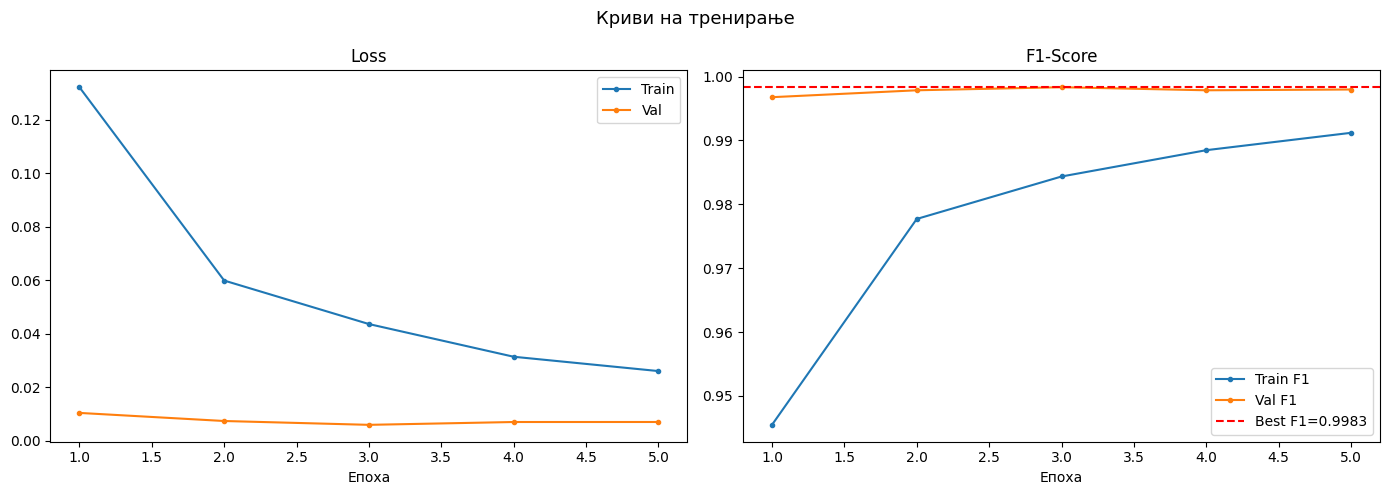

In [224]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train', marker='o', markersize=3)
axes[0].plot(ep, history['val_loss'],   label='Val',   marker='o', markersize=3)
axes[0].set_title('Loss'); axes[0].set_xlabel('Епоха'); axes[0].legend()

axes[1].plot(ep, history['train_f1'], label='Train F1', marker='o', markersize=3)
axes[1].plot(ep, history['val_f1'],   label='Val F1',   marker='o', markersize=3)
axes[1].axhline(best_f1, color='red', linestyle='--', label=f'Best F1={best_f1:.4f}')
axes[1].set_title('F1-Score'); axes[1].set_xlabel('Епоха'); axes[1].legend()

plt.suptitle('Криви на тренирање', fontsize=13)
plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/training_curves.png', dpi=150)
plt.show()

# 7. Евалуација

In [219]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

@torch.no_grad()
def get_val_predictions(model, loader):
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        preds = (torch.sigmoid(logits) > CFG.THRESHOLD).long()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_val_predictions(model, val_loader)

print('=' * 50)
print('        ЕВАЛУАЦИЈА (Val сет)')
print('=' * 50)
print(classification_report(y_true, y_pred, target_names=['REAL', 'AI']))
print(f' F1-Score (macro): {f1_score(y_true, y_pred, average="macro"):.4f}')
print(f' F1-Score (binary): {f1_score(y_true, y_pred):.4f}')

       📊 ЕВАЛУАЦИЈА (Val сет)
              precision    recall  f1-score   support

        REAL       1.00      1.00      1.00      4175
          AI       1.00      1.00      1.00      4171

    accuracy                           1.00      8346
   macro avg       1.00      1.00      1.00      8346
weighted avg       1.00      1.00      1.00      8346

🎯 F1-Score (macro): 0.9980
🎯 F1-Score (binary): 0.9980


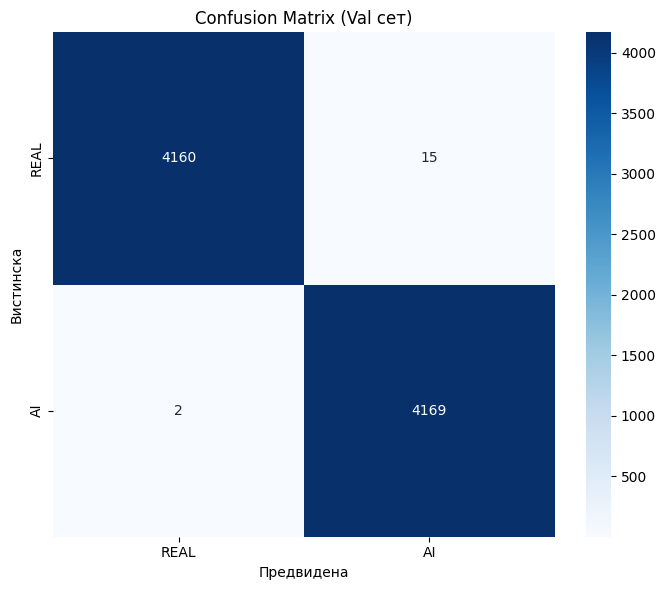

In [220]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['REAL', 'AI'], yticklabels=['REAL', 'AI'])
plt.title('Confusion Matrix (Val сет)')
plt.ylabel('Вистинска'); plt.xlabel('Предвидена')
plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/confusion_matrix.png', dpi=150)
plt.show()

# 8. Генерирање на submission.csv

In [221]:
@torch.no_grad()
def predict_test(model, loader):
    model.eval()
    all_ids, all_preds = [], []

    for imgs, ids in loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        preds = (torch.sigmoid(logits) > CFG.THRESHOLD).long()
        all_ids.extend(ids)
        all_preds.extend(preds.cpu().numpy())

    return all_ids, all_preds


test_ids, test_preds = predict_test(model, test_loader)

# Направи submission DataFrame
submission = pd.DataFrame({
    'id':    test_ids,
    'label': test_preds
})

# Осигури правилен редослед (ист како test.csv)
df_test_order = pd.read_csv(CFG.TEST_CSV)[['id']]
submission = df_test_order.merge(submission, on='id', how='left')

# Зачувај
submission_path = f'{CFG.OUTPUT_DIR}/submission.csv'
submission.to_csv(submission_path, index=False)

print(f'✅ submission.csv зачуван!')
print(f'   Редови: {len(submission):,}')
print(f'   Предвидени AI:   {(submission.label==1).sum():,}')
print(f'   Предвидени REAL: {(submission.label==0).sum():,}')
print()
submission.head(10)

✅ submission.csv зачуван!
   Редови: 5,540
   Предвидени AI:   585
   Предвидени REAL: 4,955



,id,label
0,test_data_v2/1a2d9fd3e21b4266aea1f66b30aed157.jpg,0
1,test_data_v2/ab5df8f441fe4fbf9dc9c6baae699dc7.jpg,0
2,test_data_v2/eb364dd2dfe34feda0e52466b7ce7956.jpg,0
3,test_data_v2/f76c2580e9644d85a741a42c6f6b39c0.jpg,0
4,test_data_v2/a16495c578b7494683805484ca27cf9f.jpg,0
5,test_data_v2/d08826f7ccab45c8935d8df5524b2869.jpg,0
6,test_data_v2/8ba52123cc7b4e3aa90e3947734197e0.jpg,0
7,test_data_v2/b107ac0040284f1aace7a6714bf152f7.jpg,0
8,test_data_v2/601c646d626d46da8c5fac6653efcfb8.jpg,0
9,test_data_v2/ef29ead63754441b82b56c1a22082fdf.jpg,0


In [222]:
assert list(submission.columns) == ['id', 'label'], 'Погрешни колони!'
assert len(submission) == len(df_test),             'Погрешен број на редови!'
assert submission['label'].isin([0, 1]).all(),      'Лабелите мора да се 0 или 1!'
assert submission['id'].equals(df_test_order['id']), 'Редоследот на id не е ист!'

print('✅ Submission валидацијата помина!')
print(f'   Формат: {list(submission.columns)}')
print(f'   Редови: {len(submission):,}')
print(f'   Уникатни лабели: {sorted(submission["label"].unique())}')

✅ Submission валидацијата помина!
   Формат: ['id', 'label']
   Редови: 5,540
   Уникатни лабели: [np.int64(0), np.int64(1)]


In [223]:
# Зачувај production модел со сета metadata
torch.save({
    'model_state_dict': model.state_dict(),
    'model_name':  CFG.MODEL_NAME,
    'img_size':    CFG.IMG_SIZE,
    'threshold':   CFG.THRESHOLD,
    'best_val_f1': best_f1,
    'norm_mean':   [0.485, 0.456, 0.406],
    'norm_std':    [0.229, 0.224, 0.225],
}, f'{CFG.OUTPUT_DIR}/ai_detector_production.pth')


with open(f'{CFG.OUTPUT_DIR}/inference.py', 'w') as f:
    f.write(inference_code)

print('Saved files:')
for fname in ['submission.csv', 'ai_detector_production.pth', 'inference.py', 'training_curves.png', 'confusion_matrix.png']:
    path = f'{CFG.OUTPUT_DIR}/{fname}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024**2
        print(f'   ✓ {fname} ({size:.2f} MB)')

📁 Зачувани фајлови:
   ✓ submission.csv (0.27 MB)
   ✓ ai_detector_production.pth (42.85 MB)
   ✓ inference.py (0.00 MB)
   ✓ training_curves.png (0.08 MB)
   ✓ confusion_matrix.png (0.04 MB)


In [225]:
!ls -lh /tmp/*.pth /tmp/*.py /tmp/*.csv /tmp/*.png

ls: cannot access '/tmp/*.png': No such file or directory
-rw-r--r-- 1 root root  43M Jun 21 14:49  /tmp/ai_detector_production.pth
-rw-r--r-- 1 root root 2.0K Jun 21 14:49  /tmp/inference.py
-rw-r--r-- 1 root root 282K Jun 21 14:49  /tmp/submission.csv


In [1]:
!cp /tmp/ai_detector_production.pth /kaggle/working/
!cp /tmp/inference.py /kaggle/working/
!cp /tmp/submission.csv /kaggle/working/

cp: cannot stat '/tmp/ai_detector_production.pth': No such file or directory
cp: cannot stat '/tmp/inference.py': No such file or directory
cp: cannot stat '/tmp/submission.csv': No such file or directory
